In [2]:
import pandas as pd

df = pd.read_csv("Lenskart India.csv")

print(df.head())


     order_id  order_date       city           state sales_channel  \
0  ORD1000000  2023-05-17     Bhopal  Madhya Pradesh        Online   
1  ORD1000001  2022-04-24  Faridabad         Haryana        Online   
2  ORD1000002  2022-06-05    Kolkata     West Bengal       Offline   
3  ORD1000003  2024-03-24  Ahmedabad         Gujarat       Offline   
4  ORD1000004  2024-08-17  Ahmedabad         Gujarat        Online   

         store_type  product_category  quantity  unit_price  discount_percent  \
0       Online Only        Sunglasses         3        1659                 0   
1       Online Only  Computer Glasses         1        3891                 0   
2  Standalone Store    Contact Lenses         3        4243                10   
3       Online Only        Sunglasses         3        2484                 0   
4       Online Only    Contact Lenses         2        3232                 0   

   net_sales_amount payment_mode customer_gender  customer_age  
0            4977.0  Net Ba

In [3]:
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())

(150000, 14)
Index(['order_id', 'order_date', 'city', 'state', 'sales_channel',
       'store_type', 'product_category', 'quantity', 'unit_price',
       'discount_percent', 'net_sales_amount', 'payment_mode',
       'customer_gender', 'customer_age'],
      dtype='object')
order_id             object
order_date           object
city                 object
state                object
sales_channel        object
store_type           object
product_category     object
quantity              int64
unit_price            int64
discount_percent      int64
net_sales_amount    float64
payment_mode         object
customer_gender      object
customer_age          int64
dtype: object
order_id            0
order_date          0
city                0
state               0
sales_channel       0
store_type          0
product_category    0
quantity            0
unit_price          0
discount_percent    0
net_sales_amount    0
payment_mode        0
customer_gender     0
customer_age        0
dtype: int6

In [4]:
print("Duplicates:", df.duplicated().sum())
print(df.describe())

Duplicates: 0
            quantity     unit_price  discount_percent  net_sales_amount  \
count  150000.000000  150000.000000     150000.000000     150000.000000   
mean        2.000427    2895.170913          9.747933       5229.039933   
std         0.817487    1213.293298          7.144378       3230.046503   
min         1.000000     799.000000          0.000000        599.250000   
25%         1.000000    1846.000000          5.000000       2707.200000   
50%         2.000000    2889.000000         10.000000       4290.800000   
75%         3.000000    3949.000000         15.000000       7366.100000   
max         3.000000    4998.000000         25.000000      14994.000000   

        customer_age  
count  150000.000000  
mean       41.098447  
std        13.557980  
min        18.000000  
25%        29.000000  
50%        41.000000  
75%        53.000000  
max        64.000000  


In [5]:
print(df["product_category"].value_counts())


product_category
Eyeglasses          37717
Contact Lenses      37472
Computer Glasses    37406
Sunglasses          37405
Name: count, dtype: int64


In [6]:
print(df["state"].value_counts())

state
Kerala            13194
Madhya Pradesh    13170
Odisha            13170
Maharashtra       13028
Tamil Nadu        13008
Uttar Pradesh     12979
Haryana           12873
Telangana          6639
Bihar              6584
West Bengal        6577
Delhi              6527
Gujarat            6509
Karnataka          6502
Jharkhand          6488
Chandigarh         6408
Rajasthan          6344
Name: count, dtype: int64


In [7]:
print(df["payment_mode"].value_counts())

payment_mode
Net Banking    30189
Debit Card     30063
Credit Card    30033
Cash           29962
UPI            29753
Name: count, dtype: int64


In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])
print(df["order_date"].dtype)

datetime64[ns]


In [9]:
df["year"] = df["order_date"].dt.year
print(df[["order_date", "year"]].head())

  order_date  year
0 2023-05-17  2023
1 2022-04-24  2022
2 2022-06-05  2022
3 2024-03-24  2024
4 2024-08-17  2024


In [10]:
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
print(df[["order_date", "year", "month", "month_name"]].head())

  order_date  year  month month_name
0 2023-05-17  2023      5        May
1 2022-04-24  2022      4      April
2 2022-06-05  2022      6       June
3 2024-03-24  2024      3      March
4 2024-08-17  2024      8     August


In [11]:
Q1 = df["net_sales_amount"].quantile(0.25)
Q3 = df["net_sales_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["net_sales_amount"] < lower_limit) |
    (df["net_sales_amount"] > upper_limit)
]

print("Number of outliers:", len(outliers))

Number of outliers: 530


In [12]:
df.to_csv("Lenskart_India_Cleaned.csv", index=False)
print("Cleaning completed!")

Cleaning completed!


In [13]:
data_dictionary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str)
})

print(data_dictionary)

                       Column Name       Data Type
order_id                  order_id          object
order_date              order_date  datetime64[ns]
city                          city          object
state                        state          object
sales_channel        sales_channel          object
store_type              store_type          object
product_category  product_category          object
quantity                  quantity           int64
unit_price              unit_price           int64
discount_percent  discount_percent           int64
net_sales_amount  net_sales_amount         float64
payment_mode          payment_mode          object
customer_gender    customer_gender          object
customer_age          customer_age           int64
year                          year           int32
month                        month           int32
month_name              month_name          object


In [14]:
descriptions = {
    "order_id": "Unique identification number for each order",
    "order_date": "Date on which the order was placed",
    "city": "City where the order was made",
    "state": "State where the order was made",
    "sales_channel": "Channel through which the sale was made",
    "store_type": "Type of store associated with the order",
    "product_category": "Category of the product purchased",
    "quantity": "Number of units purchased",
    "unit_price": "Price of one unit of the product",
    "discount_percent": "Discount percentage applied to the order",
    "net_sales_amount": "Final sales amount after applicable discounts",
    "payment_mode": "Method used by the customer for payment",
    "customer_gender": "Gender of the customer",
    "customer_age": "Age of the customer",
    "year": "Year extracted from the order date",
    "month": "Month number extracted from the order date",
    "month_name": "Month name extracted from the order date"
}

data_dictionary["Description"] = data_dictionary["Column Name"].map(descriptions)

print(data_dictionary)

                       Column Name       Data Type  \
order_id                  order_id          object   
order_date              order_date  datetime64[ns]   
city                          city          object   
state                        state          object   
sales_channel        sales_channel          object   
store_type              store_type          object   
product_category  product_category          object   
quantity                  quantity           int64   
unit_price              unit_price           int64   
discount_percent  discount_percent           int64   
net_sales_amount  net_sales_amount         float64   
payment_mode          payment_mode          object   
customer_gender    customer_gender          object   
customer_age          customer_age           int64   
year                          year           int32   
month                        month           int32   
month_name              month_name          object   

                           

In [15]:
data_dictionary.to_csv("Lenskart_Data_Dictionary.csv", index=False)
print("Data dictionary saved successfully!")

Data dictionary saved successfully!


In [16]:
import pandas as pd

df = pd.read_csv("Lenskart_India_Cleaned.csv")

print(df.shape)

(150000, 17)


In [17]:
print(df.describe())

            quantity     unit_price  discount_percent  net_sales_amount  \
count  150000.000000  150000.000000     150000.000000     150000.000000   
mean        2.000427    2895.170913          9.747933       5229.039933   
std         0.817487    1213.293298          7.144378       3230.046503   
min         1.000000     799.000000          0.000000        599.250000   
25%         1.000000    1846.000000          5.000000       2707.200000   
50%         2.000000    2889.000000         10.000000       4290.800000   
75%         3.000000    3949.000000         15.000000       7366.100000   
max         3.000000    4998.000000         25.000000      14994.000000   

        customer_age           year          month  
count  150000.000000  150000.000000  150000.000000  
mean       41.098447    2023.499787       6.520087  
std        13.557980       1.116110       3.450512  
min        18.000000    2022.000000       1.000000  
25%        29.000000    2023.000000       4.000000  
50%   

In [18]:
print(df["product_category"].value_counts())

product_category
Eyeglasses          37717
Contact Lenses      37472
Computer Glasses    37406
Sunglasses          37405
Name: count, dtype: int64


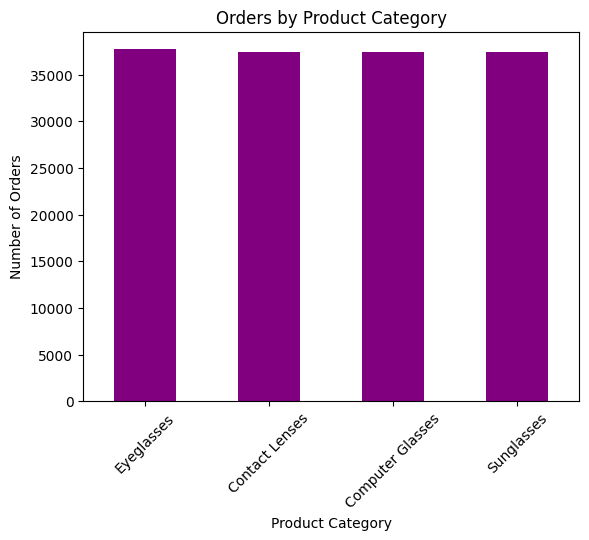

In [19]:
import matplotlib.pyplot as plt

df["product_category"].value_counts().plot(kind="bar", color="purple")

plt.title("Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [20]:
print(df["sales_channel"].value_counts())

sales_channel
Online     75190
Offline    74810
Name: count, dtype: int64


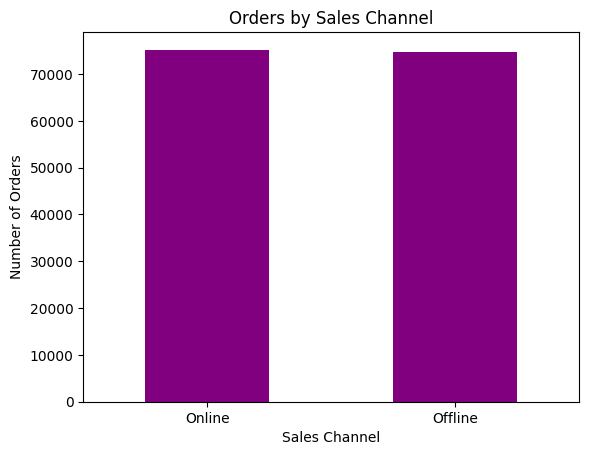

In [21]:
df["sales_channel"].value_counts().plot(
    kind="bar",
    color="purple"
)

plt.title("Orders by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [22]:
sales_by_category = df.groupby("product_category")["net_sales_amount"].sum()

print(sales_by_category)

product_category
Computer Glasses    1.954787e+08
Contact Lenses      1.958551e+08
Eyeglasses          1.979292e+08
Sunglasses          1.950930e+08
Name: net_sales_amount, dtype: float64


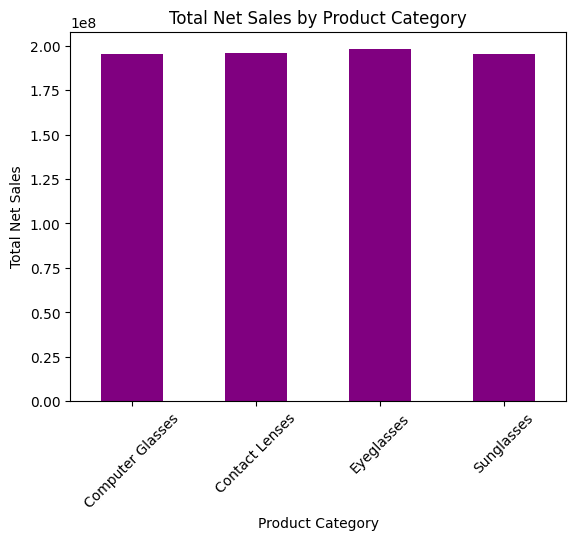

In [23]:
sales_by_category.plot(
    kind="bar",
    color="purple"
)

plt.title("Total Net Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Net Sales")
plt.xticks(rotation=45)
plt.show()

In [24]:
monthly_sales = df.groupby(["year", "month"])["net_sales_amount"].sum()

print(monthly_sales)

year  month
2022  1        16826665.05
      2        14825528.60
      3        16497006.40
      4        16573484.80
      5        16467024.70
      6        16164740.20
      7        16327617.80
      8        16095167.95
      9        16648038.80
      10       17095298.90
      11       15337246.50
      12       16568351.80
2023  1        17523535.00
      2        14448721.15
      3        16909360.60
      4        16913137.45
      5        16551045.50
      6        16640355.45
      7        16495026.55
      8        17005014.30
      9        15589851.25
      10       16721250.20
      11       16539769.35
      12       15951875.25
2024  1        16936881.15
      2        14936710.10
      3        16656145.60
      4        15772373.75
      5        16374069.20
      6        15887304.90
      7        16217968.05
      8        16156260.15
      9        16356414.10
      10       16525831.20
      11       16231218.80
      12       16930474.55
2025  1        1

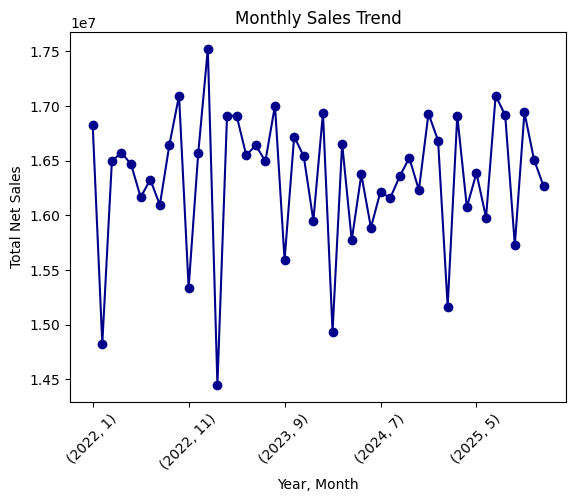

In [25]:
monthly_sales.plot(
    kind="line",
    marker="o",
    color="darkblue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year, Month")
plt.ylabel("Total Net Sales")
plt.xticks(rotation=45)
plt.show()

In [26]:
sales_by_state = df.groupby("state")["net_sales_amount"].sum()

print(sales_by_state)

state
Bihar             34415370.45
Chandigarh        33721778.75
Delhi             34010098.05
Gujarat           33989807.35
Haryana           67617659.75
Jharkhand         33745524.40
Karnataka         33774680.80
Kerala            69113389.20
Madhya Pradesh    68962157.65
Maharashtra       68238795.20
Odisha            68870112.15
Rajasthan         33478275.45
Tamil Nadu        68045504.25
Telangana         34529335.45
Uttar Pradesh     67392977.55
West Bengal       34450523.50
Name: net_sales_amount, dtype: float64


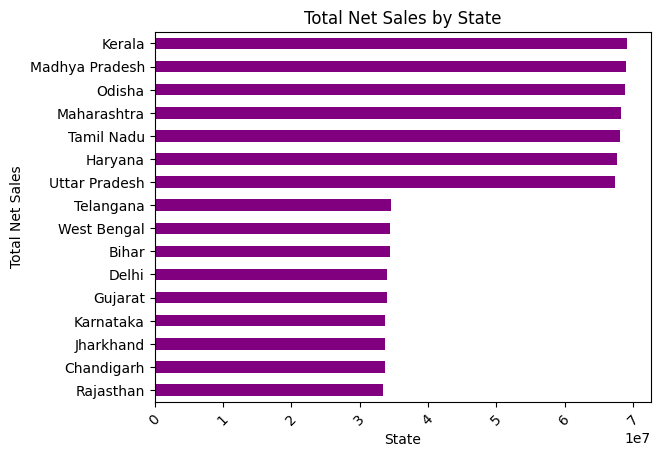

In [27]:
sales_by_state.sort_values(ascending=True).plot(
    kind="barh",
    color="purple"
)

plt.title("Total Net Sales by State")
plt.xlabel("State")
plt.ylabel("Total Net Sales")
plt.xticks(rotation=45)
plt.show()

In [28]:
avg_sales_payment = df.groupby("payment_mode")["net_sales_amount"].mean()

print(avg_sales_payment)

payment_mode
Cash           5236.077845
Credit Card    5244.717409
Debit Card     5244.557611
Net Banking    5240.680539
UPI            5178.637023
Name: net_sales_amount, dtype: float64


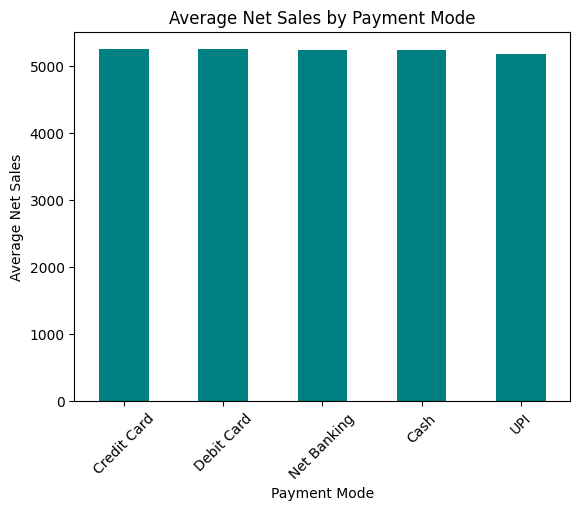

In [29]:
avg_sales_payment.sort_values(ascending=False).plot(
    kind="bar",
    color="teal"
)

plt.title("Average Net Sales by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Average Net Sales")
plt.xticks(rotation=45)
plt.show()

In [30]:
sales_by_store = df.groupby("store_type")["net_sales_amount"].sum()

print(sales_by_store)

store_type
High Street Store    9.885954e+07
Mall Store           9.695352e+07
Online Only          4.898491e+08
Standalone Store     9.869380e+07
Name: net_sales_amount, dtype: float64


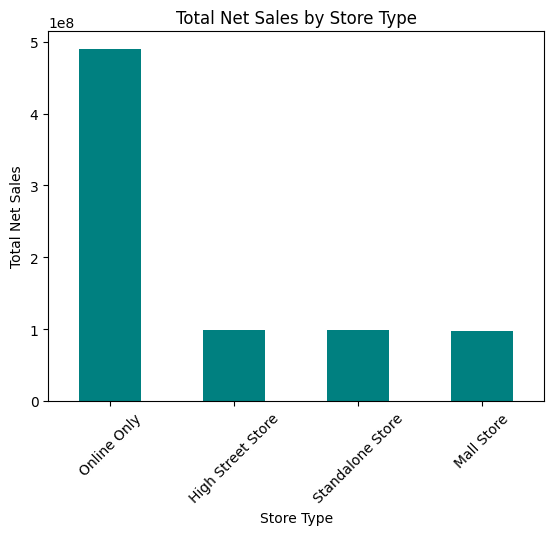

In [31]:
sales_by_store.sort_values(ascending=False).plot(
    kind="bar",
    color="teal"
)

plt.title("Total Net Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Total Net Sales")
plt.xticks(rotation=45)
plt.show()

In [32]:
print(df["customer_gender"].value_counts())


customer_gender
Male      50225
Female    49931
Other     49844
Name: count, dtype: int64


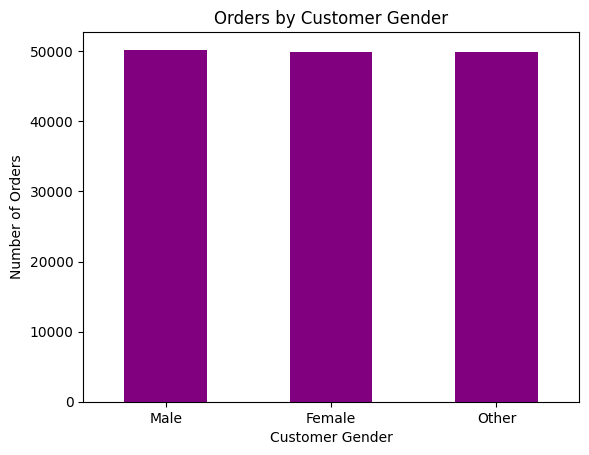

In [33]:
df["customer_gender"].value_counts().plot(
    kind="bar",
    color="purple"
)

plt.title("Orders by Customer Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

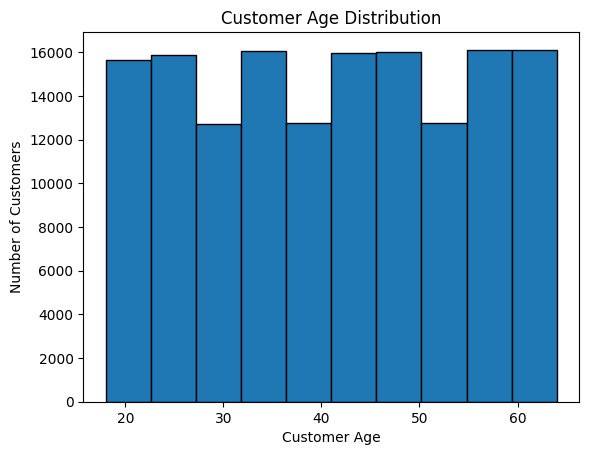

In [34]:
df["customer_age"].plot(
    kind="hist",
    bins=10,
    edgecolor="black"
)

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.show()

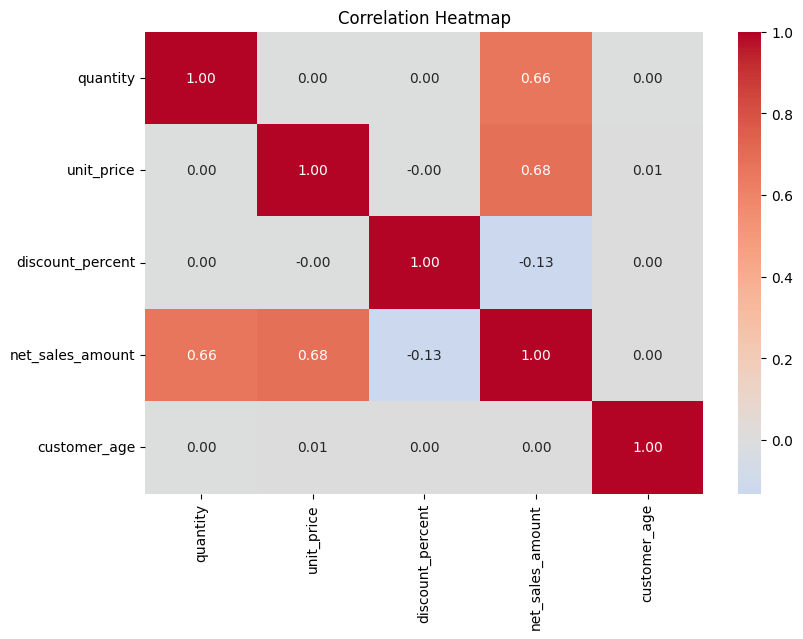

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[
    ["quantity", "unit_price", "discount_percent",
     "net_sales_amount", "customer_age"]
].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

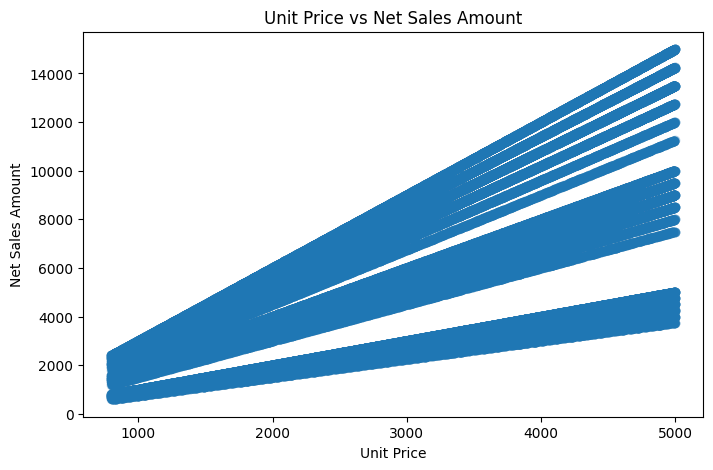

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["unit_price"],
    df["net_sales_amount"],
    alpha=0.3
)

plt.title("Unit Price vs Net Sales Amount")
plt.xlabel("Unit Price")
plt.ylabel("Net Sales Amount")

plt.show()

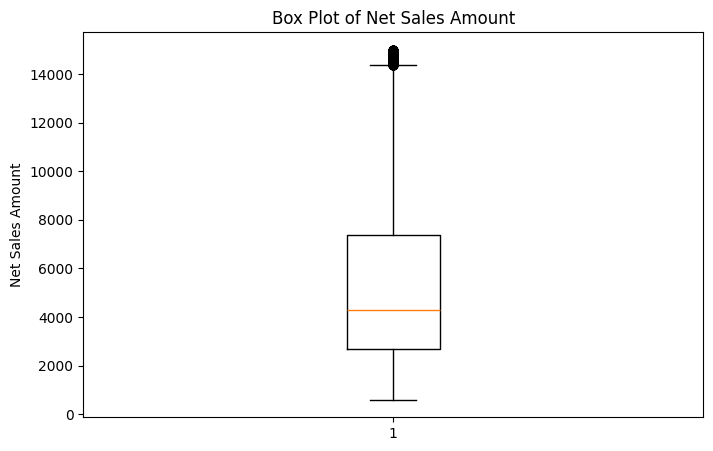

In [37]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["net_sales_amount"])

plt.title("Box Plot of Net Sales Amount")
plt.ylabel("Net Sales Amount")

plt.show()

## Key Findings from Exploratory Data Analysis

1. The dataset contains 150,000 sales records covering multiple cities, states, product categories, sales channels, and payment modes.

2. There are no missing values or duplicate records in the dataset.

3. The order date was converted into datetime format, and year, month, and month name were extracted for time-based analysis.

4. Product categories, sales channels, states, payment modes, and store types show differences in order volume and sales performance.

5. Monthly sales analysis shows changes in sales over time across different years.

6. The customer age distribution shows customers across a broad age range.

7. The correlation analysis helps identify relationships among quantity, unit price, discount percentage, net sales amount, and customer age.

8. Outlier analysis identified 530 observations in net sales amount using the IQR method. These observations were identified for further review rather than automatically removed.

In [38]:
import sqlite3
import pandas as pd

df = pd.read_csv("Lenskart_India_Cleaned.csv")

conn = sqlite3.connect("lenskart_sales.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("Database created successfully!")
print("Table 'sales' created successfully!")

Database created successfully!
Table 'sales' created successfully!


In [39]:
query = """
SELECT *
FROM sales
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

print(result)

     order_id  order_date       city           state sales_channel  \
0  ORD1000000  2023-05-17     Bhopal  Madhya Pradesh        Online   
1  ORD1000001  2022-04-24  Faridabad         Haryana        Online   
2  ORD1000002  2022-06-05    Kolkata     West Bengal       Offline   
3  ORD1000003  2024-03-24  Ahmedabad         Gujarat       Offline   
4  ORD1000004  2024-08-17  Ahmedabad         Gujarat        Online   
5  ORD1000005  2024-08-31     Jaipur       Rajasthan       Offline   
6  ORD1000006  2025-06-20  Hyderabad       Telangana        Online   
7  ORD1000007  2024-05-01  Ahmedabad         Gujarat        Online   
8  ORD1000008  2022-10-08      Patna           Bihar       Offline   
9  ORD1000009  2025-09-02    Lucknow   Uttar Pradesh       Offline   

          store_type  product_category  quantity  unit_price  \
0        Online Only        Sunglasses         3        1659   
1        Online Only  Computer Glasses         1        3891   
2   Standalone Store    Contact Lense

In [40]:
query = """
SELECT order_id, product_category, net_sales_amount
FROM sales
WHERE net_sales_amount > 5000
ORDER BY net_sales_amount DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

print(result)

     order_id  product_category  net_sales_amount
0  ORD1107498    Contact Lenses           14994.0
1  ORD1123433        Sunglasses           14994.0
2  ORD1125569    Contact Lenses           14991.0
3  ORD1003870  Computer Glasses           14988.0
4  ORD1105036    Contact Lenses           14988.0
5  ORD1129746    Contact Lenses           14988.0
6  ORD1076313        Eyeglasses           14985.0
7  ORD1133191        Eyeglasses           14985.0
8  ORD1026015        Eyeglasses           14982.0
9  ORD1095843  Computer Glasses           14982.0


In [41]:
query = """
SELECT
    product_category,
    COUNT(*) AS total_orders,
    SUM(net_sales_amount) AS total_sales,
    AVG(net_sales_amount) AS average_sales
FROM sales
GROUP BY product_category
ORDER BY total_sales DESC;
"""

result = pd.read_sql_query(query, conn)

print(result)

   product_category  total_orders   total_sales  average_sales
0        Eyeglasses         37717  1.979292e+08    5247.744265
1    Contact Lenses         37472  1.958551e+08    5226.704677
2  Computer Glasses         37406  1.954787e+08    5225.865837
3        Sunglasses         37405  1.950930e+08    5215.693205


In [42]:
# 1. Monthly sales trend
query1 = """
SELECT year, month, SUM(net_sales_amount) AS total_sales
FROM sales
GROUP BY year, month
ORDER BY year, month;
"""

monthly_sales = pd.read_sql_query(query1, conn)
print("MONTHLY SALES")
print(monthly_sales)


# 2. Top 10 orders by revenue
query2 = """
SELECT order_id, net_sales_amount
FROM sales
ORDER BY net_sales_amount DESC
LIMIT 10;
"""

top_orders = pd.read_sql_query(query2, conn)
print("\nTOP 10 ORDERS")
print(top_orders)


# 3. Product category performance
query3 = """
SELECT product_category,
       COUNT(*) AS total_orders,
       SUM(net_sales_amount) AS total_sales
FROM sales
GROUP BY product_category
ORDER BY total_sales DESC;
"""

category_performance = pd.read_sql_query(query3, conn)
print("\nCATEGORY PERFORMANCE")
print(category_performance)

MONTHLY SALES
    year  month  total_sales
0   2022      1  16826665.05
1   2022      2  14825528.60
2   2022      3  16497006.40
3   2022      4  16573484.80
4   2022      5  16467024.70
5   2022      6  16164740.20
6   2022      7  16327617.80
7   2022      8  16095167.95
8   2022      9  16648038.80
9   2022     10  17095298.90
10  2022     11  15337246.50
11  2022     12  16568351.80
12  2023      1  17523535.00
13  2023      2  14448721.15
14  2023      3  16909360.60
15  2023      4  16913137.45
16  2023      5  16551045.50
17  2023      6  16640355.45
18  2023      7  16495026.55
19  2023      8  17005014.30
20  2023      9  15589851.25
21  2023     10  16721250.20
22  2023     11  16539769.35
23  2023     12  15951875.25
24  2024      1  16936881.15
25  2024      2  14936710.10
26  2024      3  16656145.60
27  2024      4  15772373.75
28  2024      5  16374069.20
29  2024      6  15887304.90
30  2024      7  16217968.05
31  2024      8  16156260.15
32  2024      9  16356414.10


In [43]:
query = """
SELECT product_category,
       COUNT(*) AS total_orders,
       SUM(net_sales_amount) AS total_sales
FROM sales
GROUP BY product_category
HAVING SUM(net_sales_amount) > (
    SELECT AVG(category_sales)
    FROM (
        SELECT SUM(net_sales_amount) AS category_sales
        FROM sales
        GROUP BY product_category
    )
)
ORDER BY total_sales DESC;
"""

result = pd.read_sql_query(query, conn)

print(result)

  product_category  total_orders   total_sales
0       Eyeglasses         37717  1.979292e+08


In [44]:
query = """
SELECT
    order_id,
    product_category,
    net_sales_amount,
    RANK() OVER (
        ORDER BY net_sales_amount DESC
    ) AS sales_rank
FROM sales
LIMIT 20;
"""

result = pd.read_sql_query(query, conn)

print(result)

      order_id  product_category  net_sales_amount  sales_rank
0   ORD1107498    Contact Lenses           14994.0           1
1   ORD1123433        Sunglasses           14994.0           1
2   ORD1125569    Contact Lenses           14991.0           3
3   ORD1003870  Computer Glasses           14988.0           4
4   ORD1105036    Contact Lenses           14988.0           4
5   ORD1129746    Contact Lenses           14988.0           4
6   ORD1076313        Eyeglasses           14985.0           7
7   ORD1133191        Eyeglasses           14985.0           7
8   ORD1026015        Eyeglasses           14982.0           9
9   ORD1095843  Computer Glasses           14982.0           9
10  ORD1124183        Eyeglasses           14982.0           9
11  ORD1085577  Computer Glasses           14979.0          12
12  ORD1016278  Computer Glasses           14976.0          13
13  ORD1050824  Computer Glasses           14973.0          14
14  ORD1005107        Eyeglasses           14970.0     

In [45]:
query = """
SELECT product_category,
       COUNT(*) AS total_orders,
       SUM(net_sales_amount) AS total_sales,
       AVG(net_sales_amount) AS average_sales
FROM sales
GROUP BY product_category
ORDER BY total_sales DESC;
"""

result = pd.read_sql(query, conn)

print("SQL query executed successfully!")
print(result)

SQL query executed successfully!
   product_category  total_orders   total_sales  average_sales
0        Eyeglasses         37717  1.979292e+08    5247.744265
1    Contact Lenses         37472  1.958551e+08    5226.704677
2  Computer Glasses         37406  1.954787e+08    5225.865837
3        Sunglasses         37405  1.950930e+08    5215.693205


## Task 2 – SQL & Data Extraction

### Database Setup
The cleaned Lenskart sales dataset was imported into a SQLite database using Python and Pandas.

### SQL Operations Performed
- SELECT and LIMIT
- WHERE and ORDER BY
- GROUP BY
- COUNT, SUM and AVG
- HAVING
- Subqueries
- Window functions using RANK()

### Business Analysis
SQL queries were used to analyse:
- Monthly sales trends
- Top sales orders
- Product category performance
- Categories with sales above the average category-level sales

### Python-SQL Integration
Python was used to connect to the SQLite database and execute SQL queries using Pandas.

### Dataset Limitation
The dataset does not contain a customer ID or customer name column. Therefore, customer-level revenue analysis could not be performed directly. Order-level analysis was used instead.

### Task 2 Outcome
SQL was used to extract, filter, aggregate and analyse sales data, and the results were retrieved into Python for further analysis.

In [46]:
total_sales = df["net_sales_amount"].sum()
total_orders = df["order_id"].nunique()
average_order_value = df["net_sales_amount"].mean()
total_quantity = df["quantity"].sum()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)
print("Total Quantity Sold:", total_quantity)

Total Sales: 784355989.9499999
Total Orders: 150000
Average Order Value: 5229.039932999999
Total Quantity Sold: 300064


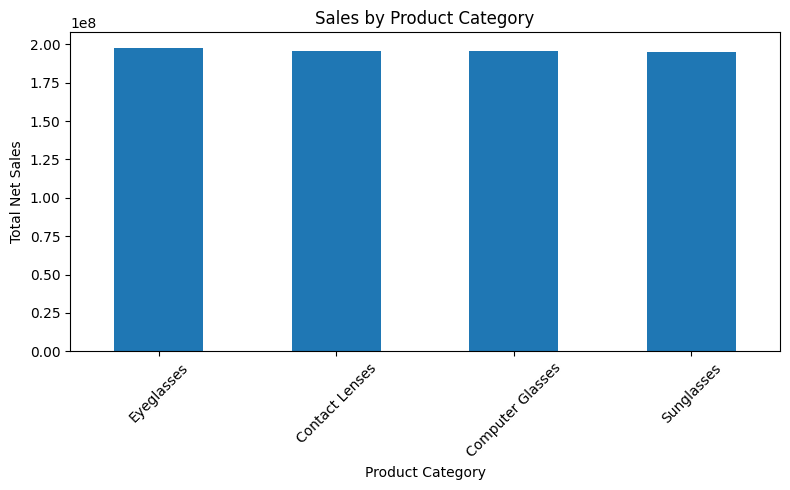

In [47]:
import matplotlib.pyplot as plt

category_sales = (
    df.groupby("product_category")["net_sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

category_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Net Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
!ls /content

 Lenskart_Data_Dictionary.csv  'Lenskart India.csv'   sample_data
 Lenskart_India_Cleaned.csv     lenskart_sales.db


In [49]:
df.describe()

,quantity,unit_price,discount_percent,net_sales_amount,customer_age,year,month
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,2.000427,2895.170913,9.747933,5229.039933,41.098447,2023.499787,6.520087
std,0.817487,1213.293298,7.144378,3230.046503,13.557980,1.116110,3.450512
min,1.000000,799.000000,0.000000,599.250000,18.000000,2022.000000,1.000000
25%,1.000000,1846.000000,5.000000,2707.200000,29.000000,2023.000000,4.000000
50%,2.000000,2889.000000,10.000000,4290.800000,41.000000,2023.000000,7.000000
75%,3.000000,3949.000000,15.000000,7366.100000,53.000000,2024.000000,10.000000
max,3.000000,4998.000000,25.000000,14994.000000,64.000000,2025.000000,12.000000


In [50]:
df[["quantity", "unit_price", "discount_percent", "net_sales_amount", "customer_age"]].agg(
    ["mean", "median", "std"]
)

,quantity,unit_price,discount_percent,net_sales_amount,customer_age
mean,2.000427,2895.170913,9.747933,5229.039933,41.098447
median,2.000000,2889.000000,10.000000,4290.800000,41.000000
std,0.817487,1213.293298,7.144378,3230.046503,13.557980


In [51]:
import scipy.stats as stats

mean_sales = df["net_sales_amount"].mean()
sem_sales = stats.sem(df["net_sales_amount"])

confidence_interval = stats.t.interval(
    0.95,
    df=len(df["net_sales_amount"]) - 1,
    loc=mean_sales,
    scale=sem_sales
)

print("Mean Net Sales:", mean_sales)
print("95% Confidence Interval:", confidence_interval)

Mean Net Sales: 5229.039932999999
95% Confidence Interval: (np.float64(5212.6938108203185), np.float64(5245.38605517968))


In [52]:
from scipy.stats import ttest_1samp

test_result = ttest_1samp(df["net_sales_amount"], 5000)

print("T-statistic:", test_result.statistic)
print("P-value:", test_result.pvalue)

T-statistic: 27.463005422248035
P-value: 1.2531643846907796e-165


In [53]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["sales_channel"], df["product_category"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 4.995544548794461
P-value: 0.17212368519215507


In [54]:
from scipy.stats import f_oneway

groups = [
    group["net_sales_amount"].values
    for _, group in df.groupby("product_category")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.6530301786354082
P-value: 0.5809421971891264


In [55]:
correlation = df["quantity"].corr(df["net_sales_amount"])

print("Correlation between Quantity and Net Sales:", correlation)

Correlation between Quantity and Net Sales: 0.6627683833182078


In [56]:
monthly_sales = df.groupby(["year", "month"])["net_sales_amount"].sum().reset_index()

print(monthly_sales)

    year  month  net_sales_amount
0   2022      1       16826665.05
1   2022      2       14825528.60
2   2022      3       16497006.40
3   2022      4       16573484.80
4   2022      5       16467024.70
5   2022      6       16164740.20
6   2022      7       16327617.80
7   2022      8       16095167.95
8   2022      9       16648038.80
9   2022     10       17095298.90
10  2022     11       15337246.50
11  2022     12       16568351.80
12  2023      1       17523535.00
13  2023      2       14448721.15
14  2023      3       16909360.60
15  2023      4       16913137.45
16  2023      5       16551045.50
17  2023      6       16640355.45
18  2023      7       16495026.55
19  2023      8       17005014.30
20  2023      9       15589851.25
21  2023     10       16721250.20
22  2023     11       16539769.35
23  2023     12       15951875.25
24  2024      1       16936881.15
25  2024      2       14936710.10
26  2024      3       16656145.60
27  2024      4       15772373.75
28  2024      

In [57]:
monthly_sales["moving_average_3m"] = (
    monthly_sales["net_sales_amount"]
    .rolling(window=3)
    .mean()
)

print(monthly_sales)

    year  month  net_sales_amount  moving_average_3m
0   2022      1       16826665.05                NaN
1   2022      2       14825528.60                NaN
2   2022      3       16497006.40       1.604973e+07
3   2022      4       16573484.80       1.596534e+07
4   2022      5       16467024.70       1.651251e+07
5   2022      6       16164740.20       1.640175e+07
6   2022      7       16327617.80       1.631979e+07
7   2022      8       16095167.95       1.619584e+07
8   2022      9       16648038.80       1.635694e+07
9   2022     10       17095298.90       1.661284e+07
10  2022     11       15337246.50       1.636019e+07
11  2022     12       16568351.80       1.633363e+07
12  2023      1       17523535.00       1.647638e+07
13  2023      2       14448721.15       1.618020e+07
14  2023      3       16909360.60       1.629387e+07
15  2023      4       16913137.45       1.609041e+07
16  2023      5       16551045.50       1.679118e+07
17  2023      6       16640355.45       1.6701

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "quantity",
    "unit_price",
    "discount_percent",
    "net_sales_amount",
    "customer_age"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(df["cluster"].value_counts().sort_index())

cluster
0    50089
1    51764
2    48147
Name: count, dtype: int64


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["quantity", "unit_price"]]
y = df["net_sales_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R² Score: 0.9015846389279958
RMSE: 1012.3810169294924


## Task 4 – Advanced Analytics & Statistical Modeling

### Analyses Performed

- Descriptive statistics were calculated for the numerical variables.
- A 95% confidence interval was calculated for average net sales.
- A one-sample t-test was performed on net sales.
- A Chi-square test examined the relationship between sales channel and product category.
- ANOVA was used to compare net sales across product categories.
- Correlation analysis examined the relationship between quantity and net sales.
- Monthly sales and a 3-month moving average were calculated for time-series analysis.
- K-Means clustering divided the sales records into three clusters.
- Linear Regression was used to predict net sales using quantity and unit price.

### Key Results

- Quantity and net sales showed a positive correlation.
- The Chi-square test did not show a statistically significant association between sales channel and product category at the 5% significance level.
- ANOVA did not show a statistically significant difference in average net sales across product categories.
- K-Means clustering created three groups of sales records.
- Linear Regression was evaluated using R² Score and RMSE.

### Outcome

Task 4 applied statistical analysis, hypothesis testing, time-series analysis, clustering, and predictive modeling to understand patterns in the Lenskart sales dataset.